In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import warnings
warnings.filterwarnings('ignore')

crop_df = pd.read_csv('/kaggle/input/crop-recommendation-dataset/Crop_recommendation.csv')
irrigation_df = pd.read_csv('/kaggle/input/irrigation-dataset2/Project_datasheet_2019-2020.csv')

print("Crop Recommendation Dataset Shape:", crop_df.shape)
print("\nCrop Dataset Info:")
print(crop_df.info())
print("\nFirst 5 rows:")
print(crop_df.head())
print("\n" + "="*80 + "\n")

print("Irrigation Dataset Shape:", irrigation_df.shape)
print("\nIrrigation Dataset Info:")
print(irrigation_df.info())
print("\nFirst 5 rows:")
print(irrigation_df.head())

Crop Recommendation Dataset Shape: (2200, 8)

Crop Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  

CROP RECOMMENDATION DATASET ANALYSIS

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate Rows: 0

Crop Distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Statistical Summary:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.

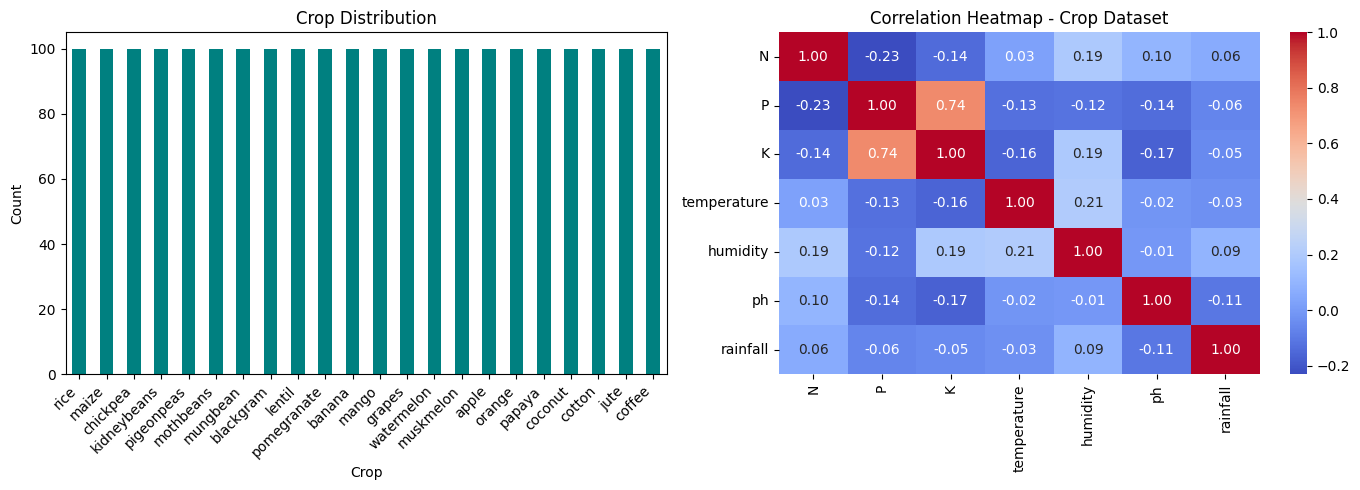


IRRIGATION DATASET ANALYSIS

Cleaned Irrigation Dataset Shape: (150, 7)

Missing Values:
CropType            0
CropDays            0
Soil Moisture       0
Soil Temperature    0
Temperature         0
Humidity            0
Irrigation(Y/N)     0
dtype: int64

Duplicate Rows: 0

Irrigation Distribution:
Irrigation(Y/N)
0    125
1     25
Name: count, dtype: int64

Crop Type Distribution:
CropType
1    100
2     50
Name: count, dtype: int64

Statistical Summary:
         CropType    CropDays  Soil Moisture  Soil Temperature  Temperature  \
count  150.000000  150.000000     150.000000         150.00000   150.000000   
mean     1.333333   50.333333     378.160000          21.32000    25.253333   
std      0.472984   28.962291     200.119665           1.83303     3.786565   
min      1.000000    1.000000     101.000000          18.00000    17.000000   
25%      1.000000   25.250000     208.750000          20.00000    23.000000   
50%      1.000000   50.500000     332.000000          21.00000  

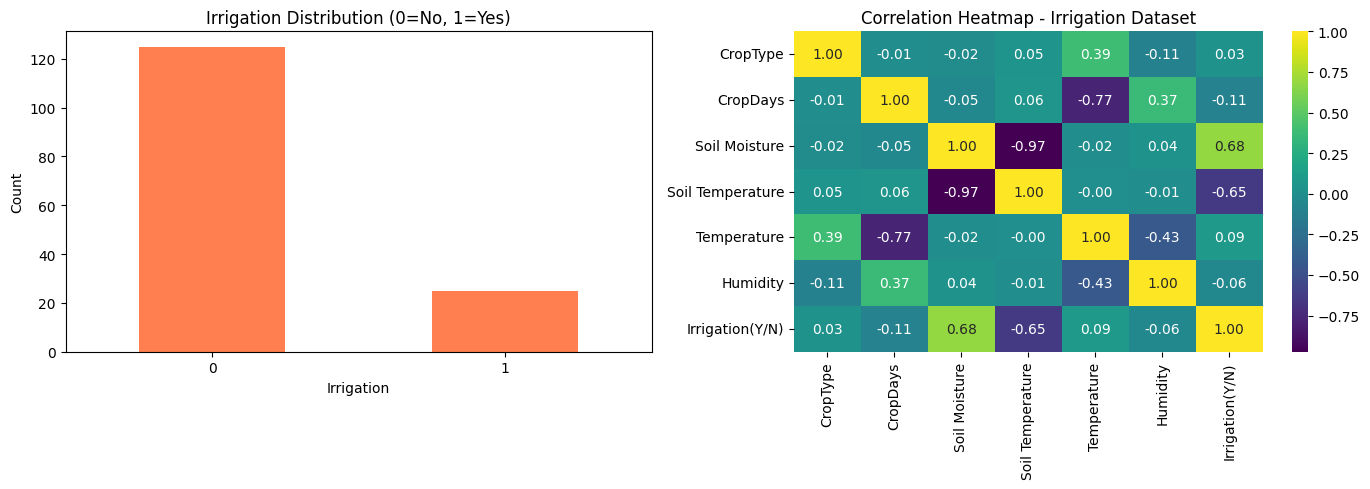

In [2]:
print("CROP RECOMMENDATION DATASET ANALYSIS")
print("="*80)
print("\nMissing Values:")
print(crop_df.isnull().sum())
print("\nDuplicate Rows:", crop_df.duplicated().sum())
print("\nCrop Distribution:")
print(crop_df['label'].value_counts())
print("\nStatistical Summary:")
print(crop_df.describe())

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
crop_df['label'].value_counts().plot(kind='bar', color='teal')
plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.heatmap(crop_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Crop Dataset')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("IRRIGATION DATASET ANALYSIS")
print("="*80)

irrigation_df = irrigation_df.drop(columns=['Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'])
print("\nCleaned Irrigation Dataset Shape:", irrigation_df.shape)
print("\nMissing Values:")
print(irrigation_df.isnull().sum())
print("\nDuplicate Rows:", irrigation_df.duplicated().sum())
print("\nIrrigation Distribution:")
print(irrigation_df['Irrigation(Y/N)'].value_counts())
print("\nCrop Type Distribution:")
print(irrigation_df['CropType'].value_counts())
print("\nStatistical Summary:")
print(irrigation_df.describe())

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
irrigation_df['Irrigation(Y/N)'].value_counts().plot(kind='bar', color='coral')
plt.title('Irrigation Distribution (0=No, 1=Yes)')
plt.xlabel('Irrigation')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
sns.heatmap(irrigation_df.corr(numeric_only=True), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap - Irrigation Dataset')
plt.tight_layout()
plt.show()

CROP RECOMMENDATION MODEL - PREPROCESSING
Crop Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']
Number of Crops: 22

Training Set: (1760, 7)
Testing Set: (440, 7)

IRRIGATION MODEL - PREPROCESSING & BALANCING
Before Balancing:
Irrigation(Y/N)
0    125
1     25
Name: count, dtype: int64

After Upsampling:
Irrigation(Y/N)
1    125
0    125
Name: count, dtype: int64

Training Set: (200, 6)
Testing Set: (50, 6)


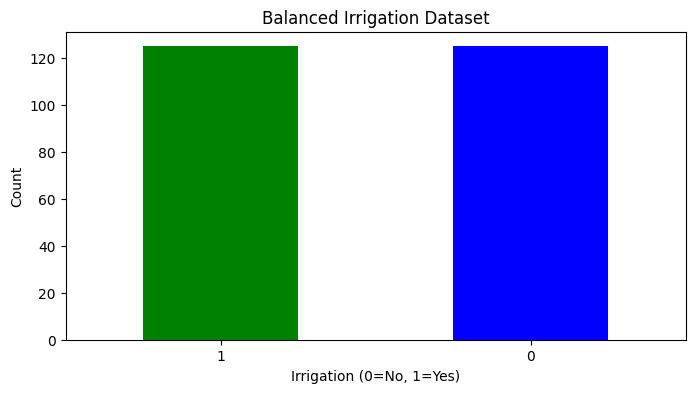

In [5]:
print("CROP RECOMMENDATION MODEL - PREPROCESSING")
print("="*80)

X_crop = crop_df.drop('label', axis=1)
y_crop = crop_df['label']

le_crop = LabelEncoder()
y_crop_encoded = le_crop.fit_transform(y_crop)

print("Crop Classes:", le_crop.classes_)
print("Number of Crops:", len(le_crop.classes_))

scaler_crop = StandardScaler()
X_crop_scaled = scaler_crop.fit_transform(X_crop)

X_crop_train, X_crop_test, y_crop_train, y_crop_test = train_test_split(
    X_crop_scaled, y_crop_encoded, test_size=0.2, random_state=42, stratify=y_crop_encoded
)

print(f"\nTraining Set: {X_crop_train.shape}")
print(f"Testing Set: {X_crop_test.shape}")

print("\n" + "="*80)
print("IRRIGATION MODEL - PREPROCESSING & BALANCING")
print("="*80)

X_irrigation = irrigation_df.drop('Irrigation(Y/N)', axis=1)
y_irrigation = irrigation_df['Irrigation(Y/N)']

print("Before Balancing:")
print(y_irrigation.value_counts())

scaler_irrigation = StandardScaler()

from sklearn.utils import resample

df_majority = irrigation_df[irrigation_df['Irrigation(Y/N)'] == 0]
df_minority = irrigation_df[irrigation_df['Irrigation(Y/N)'] == 1]

df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter Upsampling:")
print(df_balanced['Irrigation(Y/N)'].value_counts())

X_irrigation_balanced = df_balanced.drop('Irrigation(Y/N)', axis=1)
y_irrigation_balanced = df_balanced['Irrigation(Y/N)']

X_irrigation_balanced_scaled = scaler_irrigation.fit_transform(X_irrigation_balanced)

X_irr_train, X_irr_test, y_irr_train, y_irr_test = train_test_split(
    X_irrigation_balanced_scaled, y_irrigation_balanced, test_size=0.2, random_state=42, stratify=y_irrigation_balanced
)

print(f"\nTraining Set: {X_irr_train.shape}")
print(f"Testing Set: {X_irr_test.shape}")

plt.figure(figsize=(8, 4))
df_balanced['Irrigation(Y/N)'].value_counts().plot(kind='bar', color=['green', 'blue'])
plt.title('Balanced Irrigation Dataset')
plt.xlabel('Irrigation (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

TRAINING CROP RECOMMENDATION MODEL
Crop Model Training Accuracy: 100.00%
Crop Model Testing Accuracy: 99.55%

TRAINING IRRIGATION MODEL
Irrigation Model Training Accuracy: 100.00%
Irrigation Model Testing Accuracy: 98.00%

Crop Model - Top 5 Important Features:
    Feature  Importance
6  Rainfall    0.230184
4  Humidity    0.224227
2         K    0.175393
1         P    0.150850
0         N    0.096363

Irrigation Model - Top Features:
            Feature  Importance
2     Soil Moisture    0.420361
3  Soil Temperature    0.394049
1          CropDays    0.083485
5          Humidity    0.060805
4       Temperature    0.034387
0          CropType    0.006914


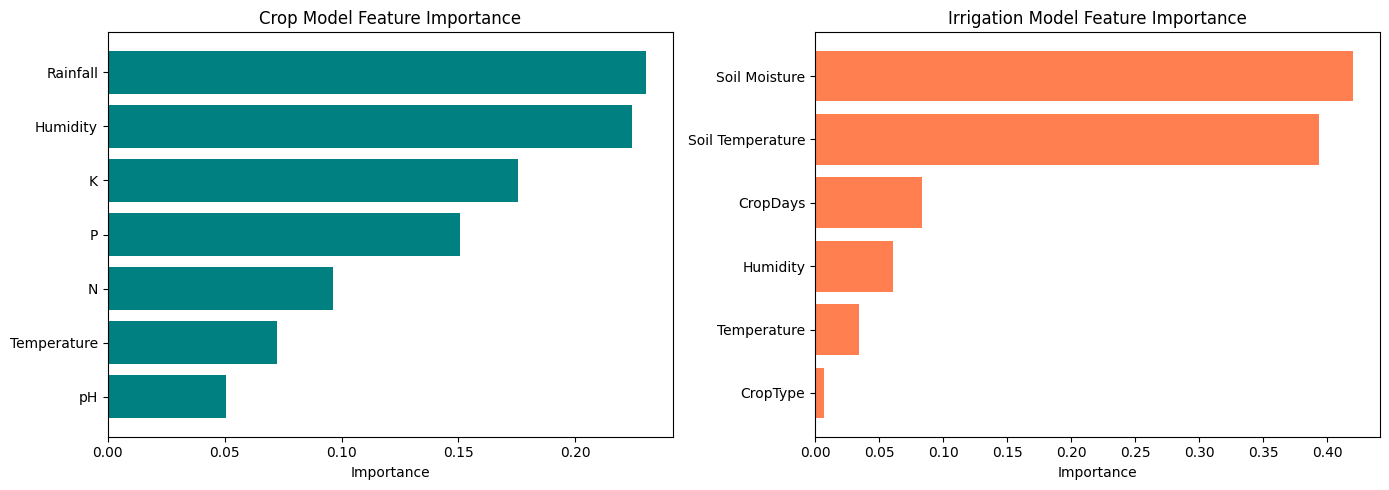

In [6]:
print("TRAINING CROP RECOMMENDATION MODEL")
print("="*80)

rf_crop = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_crop.fit(X_crop_train, y_crop_train)

y_crop_pred = rf_crop.predict(X_crop_test)
crop_accuracy = accuracy_score(y_crop_test, y_crop_pred)

print(f"Crop Model Training Accuracy: {rf_crop.score(X_crop_train, y_crop_train)*100:.2f}%")
print(f"Crop Model Testing Accuracy: {crop_accuracy*100:.2f}%")

print("\n" + "="*80)
print("TRAINING IRRIGATION MODEL")
print("="*80)

rf_irrigation = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_irrigation.fit(X_irr_train, y_irr_train)

y_irr_pred = rf_irrigation.predict(X_irr_test)
irrigation_accuracy = accuracy_score(y_irr_test, y_irr_pred)

print(f"Irrigation Model Training Accuracy: {rf_irrigation.score(X_irr_train, y_irr_train)*100:.2f}%")
print(f"Irrigation Model Testing Accuracy: {irrigation_accuracy*100:.2f}%")

feature_names_crop = ['N', 'P', 'K', 'Temperature', 'Humidity', 'pH', 'Rainfall']
feature_importance_crop = pd.DataFrame({
    'Feature': feature_names_crop,
    'Importance': rf_crop.feature_importances_
}).sort_values('Importance', ascending=False)

feature_names_irrigation = ['CropType', 'CropDays', 'Soil Moisture', 'Soil Temperature', 'Temperature', 'Humidity']
feature_importance_irrigation = pd.DataFrame({
    'Feature': feature_names_irrigation,
    'Importance': rf_irrigation.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nCrop Model - Top 5 Important Features:")
print(feature_importance_crop.head())

print("\nIrrigation Model - Top Features:")
print(feature_importance_irrigation)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.barh(feature_importance_crop['Feature'], feature_importance_crop['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Crop Model Feature Importance')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(feature_importance_irrigation['Feature'], feature_importance_irrigation['Importance'], color='coral')
plt.xlabel('Importance')
plt.title('Irrigation Model Feature Importance')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

CROP RECOMMENDATION MODEL - DETAILED EVALUATION
Accuracy:  99.55%
Precision: 99.57%
Recall:    99.55%
F1-Score:  99.55%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00  

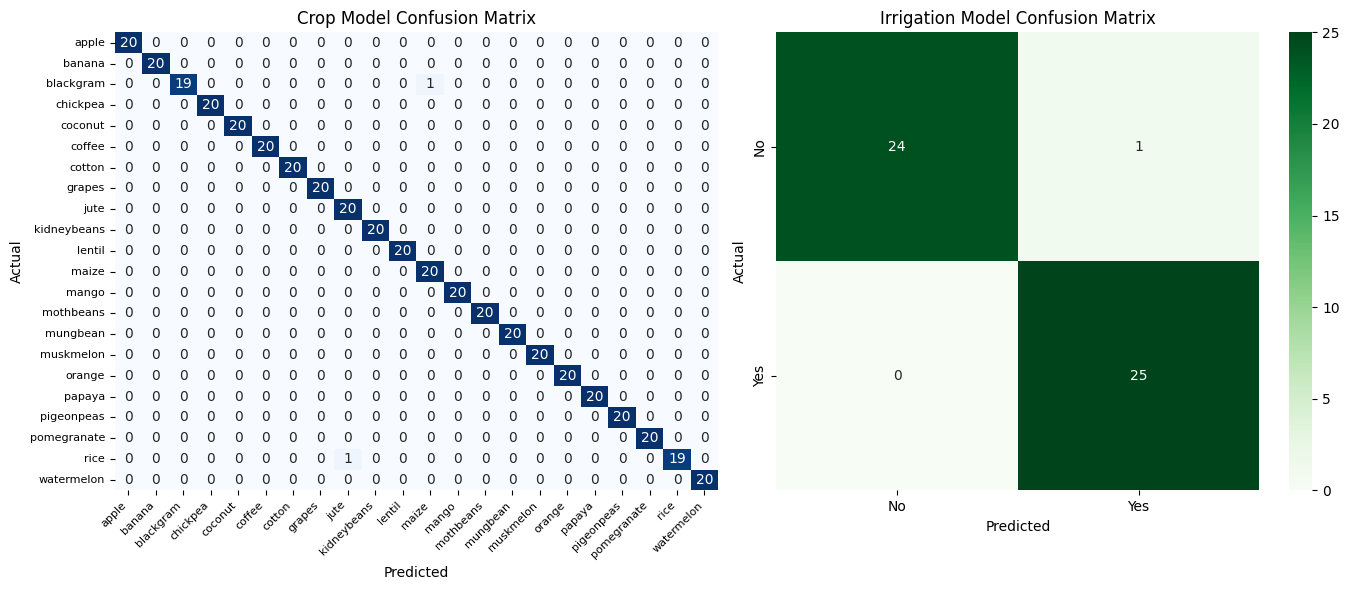

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("CROP RECOMMENDATION MODEL - DETAILED EVALUATION")
print("="*80)

crop_precision = precision_score(y_crop_test, y_crop_pred, average='weighted')
crop_recall = recall_score(y_crop_test, y_crop_pred, average='weighted')
crop_f1 = f1_score(y_crop_test, y_crop_pred, average='weighted')

print(f"Accuracy:  {crop_accuracy*100:.2f}%")
print(f"Precision: {crop_precision*100:.2f}%")
print(f"Recall:    {crop_recall*100:.2f}%")
print(f"F1-Score:  {crop_f1*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_crop_test, y_crop_pred, target_names=le_crop.classes_))

print("\n" + "="*80)
print("IRRIGATION MODEL - DETAILED EVALUATION")
print("="*80)

irr_precision = precision_score(y_irr_test, y_irr_pred, average='weighted')
irr_recall = recall_score(y_irr_test, y_irr_pred, average='weighted')
irr_f1 = f1_score(y_irr_test, y_irr_pred, average='weighted')

print(f"Accuracy:  {irrigation_accuracy*100:.2f}%")
print(f"Precision: {irr_precision*100:.2f}%")
print(f"Recall:    {irr_recall*100:.2f}%")
print(f"F1-Score:  {irr_f1*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_irr_test, y_irr_pred, target_names=['No Irrigation', 'Irrigate']))

cm_crop = confusion_matrix(y_crop_test, y_crop_pred)
cm_irrigation = confusion_matrix(y_irr_test, y_irr_pred)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm_crop, annot=True, fmt='d', cmap='Blues', xticklabels=le_crop.classes_, yticklabels=le_crop.classes_, cbar=False)
plt.title('Crop Model Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.subplot(1, 2, 2)
sns.heatmap(cm_irrigation, annot=True, fmt='d', cmap='Greens', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Irrigation Model Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

In [8]:
print("CROP RECOMMENDATION MODEL - RANDOM PREDICTIONS")
print("="*80)

random_indices_crop = np.random.choice(len(X_crop_test), 5, replace=False)

for idx in random_indices_crop:
    actual_label = le_crop.inverse_transform([y_crop_test[idx]])[0]
    predicted_label = le_crop.inverse_transform([y_crop_pred[idx]])[0]
    probabilities = rf_crop.predict_proba([X_crop_test[idx]])[0]
    confidence = max(probabilities) * 100
    
    print(f"\nSample {idx}:")
    print(f"Actual Crop: {actual_label}")
    print(f"Predicted Crop: {predicted_label}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Status: {'✓ Correct' if actual_label == predicted_label else '✗ Wrong'}")

print("\n" + "="*80)
print("IRRIGATION MODEL - RANDOM PREDICTIONS")
print("="*80)

random_indices_irr = np.random.choice(len(X_irr_test), 5, replace=False)

for idx in random_indices_irr:
    actual = 'Irrigate' if y_irr_test.iloc[idx] == 1 else 'No Irrigation'
    predicted = 'Irrigate' if y_irr_pred[idx] == 1 else 'No Irrigation'
    probabilities = rf_irrigation.predict_proba([X_irr_test[idx]])[0]
    confidence = max(probabilities) * 100
    
    print(f"\nSample {idx}:")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Status: {'✓ Correct' if actual == predicted else '✗ Wrong'}")

print("\n" + "="*80)
print("CUSTOM INPUT PREDICTIONS")
print("="*80)

sample_crop_input = np.array([[90, 42, 43, 20.87, 82.00, 6.50, 202.93]])
sample_crop_scaled = scaler_crop.transform(sample_crop_input)
crop_prediction = rf_crop.predict(sample_crop_scaled)
crop_proba = rf_crop.predict_proba(sample_crop_scaled)[0]
predicted_crop = le_crop.inverse_transform(crop_prediction)[0]
confidence_crop = max(crop_proba) * 100

print("\nCrop Recommendation Test:")
print(f"Input: N=90, P=42, K=43, Temp=20.87°C, Humidity=82%, pH=6.5, Rainfall=202.93mm")
print(f"Recommended Crop: {predicted_crop.upper()}")
print(f"Confidence: {confidence_crop:.2f}%")

sample_irr_input = np.array([[1, 50, 150, 24, 28, 55]])
sample_irr_scaled = scaler_irrigation.transform(sample_irr_input)
irr_prediction = rf_irrigation.predict(sample_irr_scaled)
irr_proba = rf_irrigation.predict_proba(sample_irr_scaled)[0]
predicted_irr = 'YES - Irrigate Now' if irr_prediction[0] == 1 else 'NO - Do Not Irrigate'
confidence_irr = max(irr_proba) * 100

print("\nIrrigation Advisory Test:")
print(f"Input: CropType=Paddy, CropDays=50, SoilMoisture=150, SoilTemp=24°C, Temp=28°C, Humidity=55%")
print(f"Irrigation Decision: {predicted_irr}")
print(f"Confidence: {confidence_irr:.2f}%")

CROP RECOMMENDATION MODEL - RANDOM PREDICTIONS

Sample 46:
Actual Crop: cotton
Predicted Crop: cotton
Confidence: 96.00%
Status: ✓ Correct

Sample 59:
Actual Crop: lentil
Predicted Crop: lentil
Confidence: 99.00%
Status: ✓ Correct

Sample 415:
Actual Crop: coconut
Predicted Crop: coconut
Confidence: 98.00%
Status: ✓ Correct

Sample 157:
Actual Crop: muskmelon
Predicted Crop: muskmelon
Confidence: 100.00%
Status: ✓ Correct

Sample 65:
Actual Crop: rice
Predicted Crop: rice
Confidence: 98.00%
Status: ✓ Correct

IRRIGATION MODEL - RANDOM PREDICTIONS

Sample 18:
Actual: No Irrigation
Predicted: No Irrigation
Confidence: 100.00%
Status: ✓ Correct

Sample 5:
Actual: Irrigate
Predicted: Irrigate
Confidence: 100.00%
Status: ✓ Correct

Sample 8:
Actual: Irrigate
Predicted: Irrigate
Confidence: 100.00%
Status: ✓ Correct

Sample 9:
Actual: No Irrigation
Predicted: No Irrigation
Confidence: 100.00%
Status: ✓ Correct

Sample 3:
Actual: No Irrigation
Predicted: No Irrigation
Confidence: 100.00%
Stat

In [9]:
print("SAVING MODELS AND ARTIFACTS")
print("="*80)

with open('crop_recommendation_model.pkl', 'wb') as f:
    pickle.dump(rf_crop, f)
print("✓ Crop Recommendation Model saved: crop_recommendation_model.pkl")

with open('irrigation_model.pkl', 'wb') as f:
    pickle.dump(rf_irrigation, f)
print("✓ Irrigation Model saved: irrigation_model.pkl")

with open('crop_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_crop, f)
print("✓ Crop Label Encoder saved: crop_label_encoder.pkl")

with open('crop_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_crop, f)
print("✓ Crop Scaler saved: crop_scaler.pkl")

with open('irrigation_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_irrigation, f)
print("✓ Irrigation Scaler saved: irrigation_scaler.pkl")

print("\n" + "="*80)
print("LIBRARY VERSIONS")
print("="*80)

import sys
import sklearn

print(f"Python Version: {sys.version.split()[0]}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-learn Version: {sklearn.__version__}")
print(f"Matplotlib Version: {plt.matplotlib.__version__}")
print(f"Seaborn Version: {sns.__version__}")

print("\n" + "="*80)
print("MODEL SUMMARY")
print("="*80)

print("\nCROP RECOMMENDATION MODEL:")
print(f"  Algorithm: Random Forest Classifier")
print(f"  Training Samples: {len(X_crop_train)}")
print(f"  Testing Samples: {len(X_crop_test)}")
print(f"  Number of Classes: {len(le_crop.classes_)}")
print(f"  Features: {len(feature_names_crop)}")
print(f"  Test Accuracy: {crop_accuracy*100:.2f}%")
print(f"  F1-Score: {crop_f1*100:.2f}%")

print("\nIRRIGATION MODEL:")
print(f"  Algorithm: Random Forest Classifier")
print(f"  Training Samples: {len(X_irr_train)}")
print(f"  Testing Samples: {len(X_irr_test)}")
print(f"  Number of Classes: 2 (Yes/No)")
print(f"  Features: {len(feature_names_irrigation)}")
print(f"  Test Accuracy: {irrigation_accuracy*100:.2f}%")
print(f"  F1-Score: {irr_f1*100:.2f}%")

print("\n" + "="*80)
print("TRAINING COMPLETED SUCCESSFULLY!")
print("="*80)

SAVING MODELS AND ARTIFACTS
✓ Crop Recommendation Model saved: crop_recommendation_model.pkl
✓ Irrigation Model saved: irrigation_model.pkl
✓ Crop Label Encoder saved: crop_label_encoder.pkl
✓ Crop Scaler saved: crop_scaler.pkl
✓ Irrigation Scaler saved: irrigation_scaler.pkl

LIBRARY VERSIONS
Python Version: 3.11.13
NumPy Version: 1.26.4
Pandas Version: 2.2.3
Scikit-learn Version: 1.2.2
Matplotlib Version: 3.7.2
Seaborn Version: 0.12.2

MODEL SUMMARY

CROP RECOMMENDATION MODEL:
  Algorithm: Random Forest Classifier
  Training Samples: 1760
  Testing Samples: 440
  Number of Classes: 22
  Features: 7
  Test Accuracy: 99.55%
  F1-Score: 99.55%

IRRIGATION MODEL:
  Algorithm: Random Forest Classifier
  Training Samples: 200
  Testing Samples: 50
  Number of Classes: 2 (Yes/No)
  Features: 6
  Test Accuracy: 98.00%
  F1-Score: 98.00%

TRAINING COMPLETED SUCCESSFULLY!


In [10]:
!zip -r model.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/crop_recommendation_model.pkl (deflated 91%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 75%)
  adding: kaggle/working/irrigation_scaler.pkl (deflated 26%)
  adding: kaggle/working/irrigation_model.pkl (deflated 85%)
  adding: kaggle/working/crop_scaler.pkl (deflated 23%)
  adding: kaggle/working/crop_label_encoder.pkl (deflated 27%)


In [11]:
from IPython.display import FileLink
FileLink(r'model.zip')


/kaggle/working/model.zip